<a href="https://colab.research.google.com/github/ayatayoub20/adult-income-classification/blob/main/adult_income_classification_project_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

In [2]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None,
        cmap='gist_gray',
        colorbar=colorbar,
        ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize,
        cmap=cmap,
        colorbar=colorbar,
        ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred,
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_train,
        colorbar=colorbar,
        label='Training Data'
    )

    print()

    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred,
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_test,
        colorbar=colorbar,
        label='Test Data'
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}


In [3]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week10/Data/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [5]:
df.duplicated().sum()
df = df.drop_duplicates()

## Dataset Choice

I chose the Adult Income dataset. The goal is to predict whether a person's income is greater than 50K or less than or equal to 50K.

The target column is `income`.

Each row represents one person.

This is a classification task because the target has two categories: `>50K` and `<=50K`.

The dataset includes demographic and employment-related features such as age, education, occupation, marital status, hours worked per week, and capital gain/loss.

Possible challenges include missing values represented as `?`, categorical variables that need encoding, and potential class imbalance.

In [6]:
target = 'income'

X = df.drop(columns=target)
y = df[target]

y.value_counts(normalize=True)

,proportion
income,
<=50K,0.760586
>50K,0.239414


#target distribution

In [7]:
y.value_counts()

,count
income,
<=50K,37109
>50K,11681


In [8]:
y.value_counts(normalize=True)

,proportion
income,
<=50K,0.760586
>50K,0.239414


#EDA

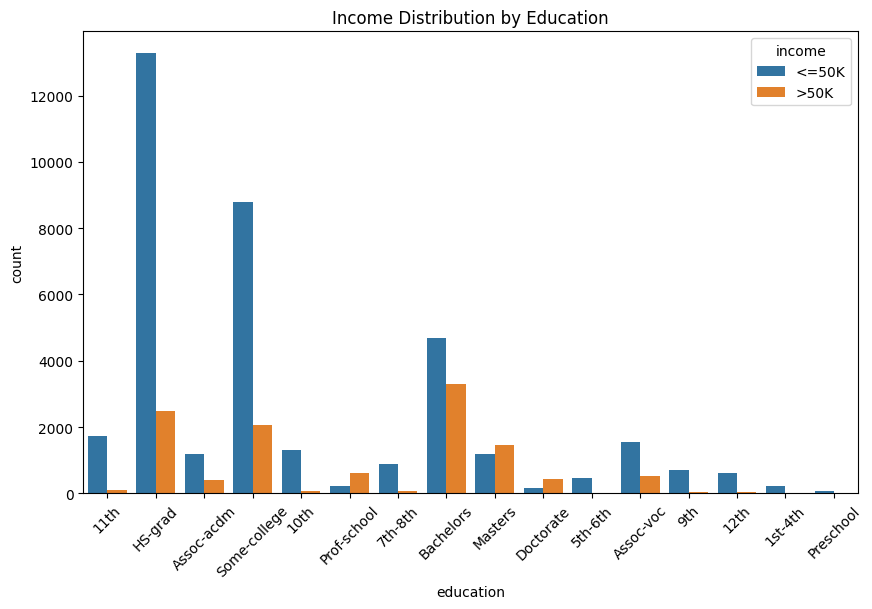

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='education',
    hue='income'
)

plt.title('Income Distribution by Education')
plt.xticks(rotation=45)
plt.show()

### Insight: Education Level and Income

The visualization shows a clear relationship between education level and income. Individuals with higher education levels such as Bachelor's, Master's, Professional School, and Doctorate degrees have a noticeably higher proportion of income greater than 50K compared to lower education levels.

On the other hand, individuals with lower education levels such as HS-grad, 11th, 10th, and Preschool are much more likely to earn less than or equal to 50K.

This suggests that education plays an important role in determining income level and may strongly influence career opportunities and earning potential.

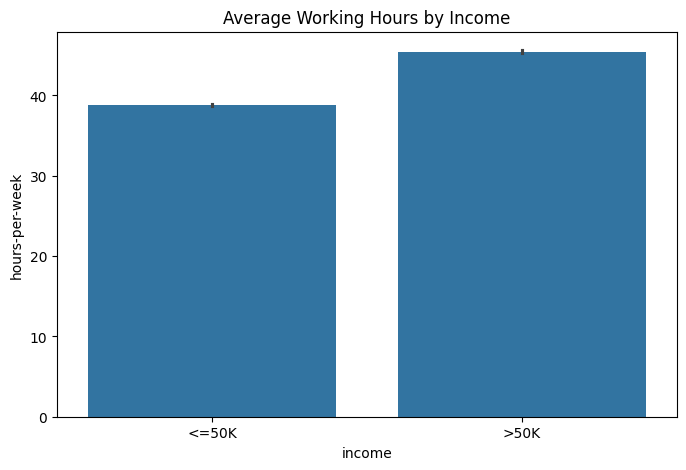

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Average Working Hours by Income')
plt.show()

### Insight: Working Hours and Income

The visualization shows that individuals earning more than 50K tend to work more hours per week on average compared to individuals earning less than or equal to 50K.

This trend may indicate that higher-income jobs often require longer working hours, greater responsibility, or more demanding positions.

The relationship between working hours and income appears to be positively associated in this dataset.

In [13]:
target = 'income'

X = df.drop(columns=target)

y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
num_selector = make_column_selector(dtype_include='number')
cat_selector = make_column_selector(dtype_include='object')

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_selector),
        ('cat', cat_pipe, cat_selector)
    ],
    verbose_feature_names_out=False
)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     29687
        >50K       1.00      1.00      1.00      9345

    accuracy                           1.00     39032
   macro avg       1.00      1.00      1.00     39032
weighted avg       1.00      1.00      1.00     39032



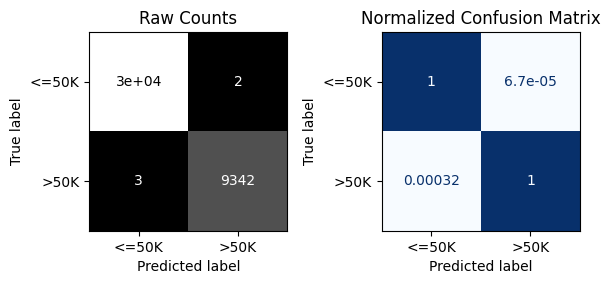


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.90      0.88      0.89      7422
        >50K       0.65      0.70      0.68      2336

    accuracy                           0.84      9758
   macro avg       0.78      0.79      0.79      9758
weighted avg       0.84      0.84      0.84      9758



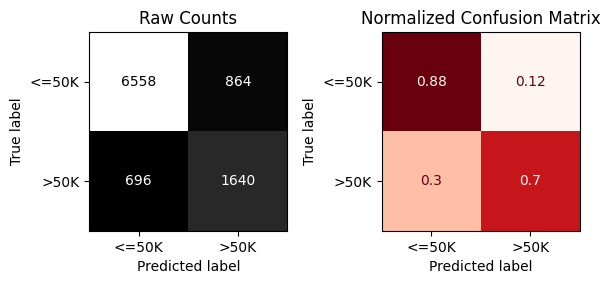

In [17]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

rf_smote_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_smote_pipe.fit(X_train, y_train)

evaluate_classification(
    rf_smote_pipe,
    X_train, y_train,
    X_test, y_test
)

## Model Evaluation

The Random Forest model achieved an accuracy of approximately 84% on the test data.

The model performed very well on the majority class (`<=50K`) and showed reasonable performance on the minority class (`>50K`).

The recall score for the `>50K` class was 0.70, which means the model successfully identified around 70% of higher-income individuals. This improvement is important because the dataset contains class imbalance.

SMOTE helped improve the model's ability to learn patterns from the minority class by generating synthetic training examples.

The training performance reached nearly perfect scores, while the test performance was lower, suggesting that the model may be slightly overfitting the training data.

#Permutation Importance

In [18]:
result = permutation_importance(
    rf_smote_pipe,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='accuracy'
)

In [19]:
feature_names = rf_smote_pipe.named_steps[
    'preprocessor'
].get_feature_names_out()

In [21]:
feature_names = X_test.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
})

In [22]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [23]:
top10 = importance_df.head(10)

top10

,Feature,Importance
10,capital-gain,0.035581
5,marital-status,0.014163
6,occupation,0.013240
0,age,0.011355
4,educational-num,0.010125
12,hours-per-week,0.008260
3,education,0.005595
11,capital-loss,0.005595
2,fnlwgt,0.003238
1,workclass,0.002705


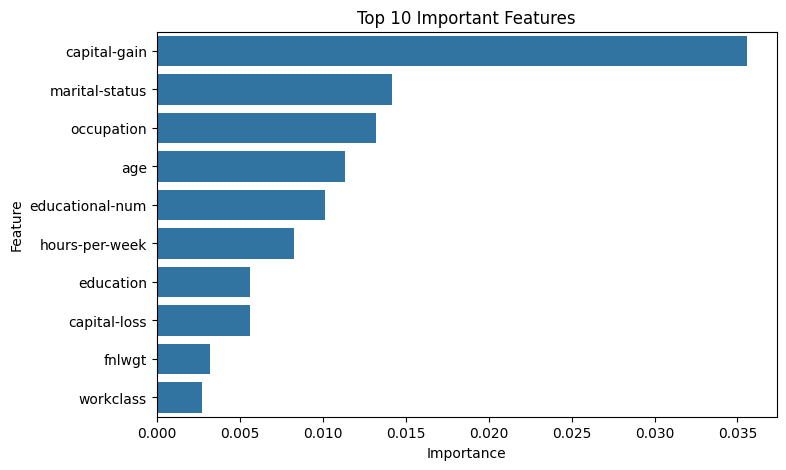

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.show()

## Permutation Importance Observations

The most important feature in the model is `capital-gain`, which means that investment-related income has a strong influence on predicting whether a person earns more than 50K.

Other important features include `marital-status`, `occupation`, `age`, `educational-num`, and `hours-per-week`. These features make sense because income is usually related to a person's job type, education level, age, work experience, and working hours.

Overall, the top features are reasonable for this business case because they reflect financial, demographic, and employment-related factors that are expected to affect income.

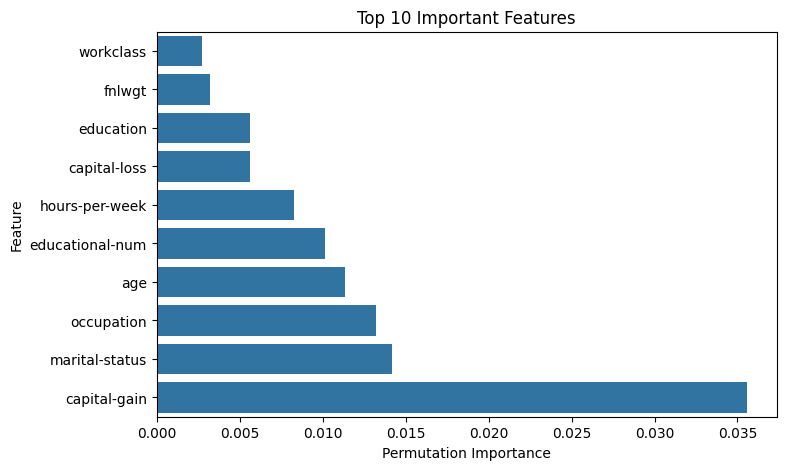

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top10.sort_values('Importance'),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.show()

#Explanatory Visualizations

##Capital Gain vs Income

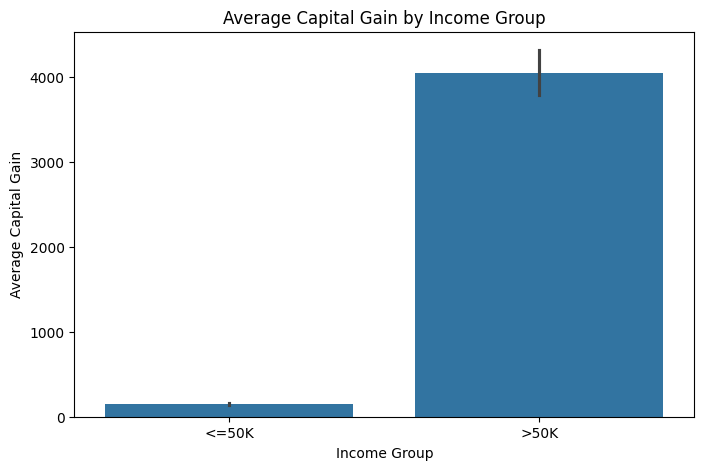

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='income',
    y='capital-gain'
)

plt.title('Average Capital Gain by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Capital Gain')

plt.show()

##Hours Worked vs Income

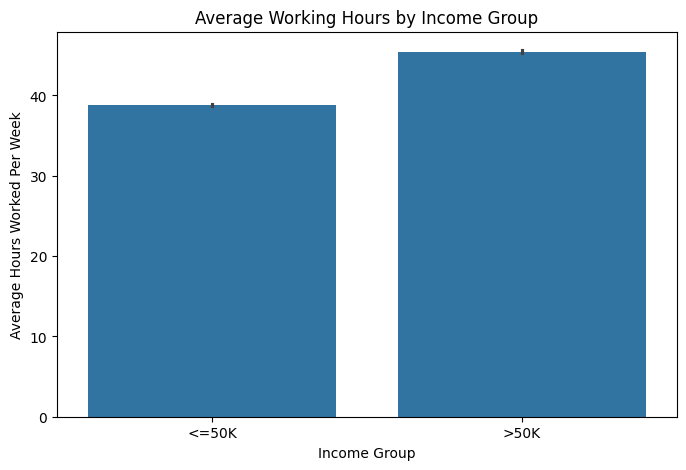

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Average Working Hours by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Hours Worked Per Week')

plt.show()